# Administrative boundaries — Natural Earth & US Census TIGER

Beyond per-country geoBoundaries, the admin backend serves **global cultural layers**
([Natural Earth](https://www.naturalearthdata.com/)) and **US Census TIGER/Line**
cartographic boundaries. This notebook maps both and shows the automatic CRS
normalisation to EPSG:4326.

## Setup

In [1]:
import matplotlib.pyplot as plt
from earthlens.core import EarthLens

## Natural Earth — world countries

Natural Earth ships cultural layers at three scales (`10m` / `50m` / `110m`). The
`scale=` selector is optional and defaults per dataset (`110m` for countries). We
use the coarse `110m` layer here — it is tiny (~200 KB) and fast.

In [2]:
countries = EarthLens(
    data_source='natural-earth',
    variables=['natural_earth:countries'],
    scale='110m',
).download(progress_bar=False)
print(len(countries), 'countries, EPSG:', countries.crs.to_epsg())

2026-06-28 16:47:51 | INFO | pyramids.base.config | Logging is configured.


2026-06-28 16:47:52.557 | INFO     | earthlens.earthlens:__init__:1012 - No `path` given; download() writes 'natural-earth' output under earthlens-data\natural-earth/ (load() uses a temp dir).


2026-06-28 16:47:52.574 | INFO     | earthlens.admin.backend:_fetch:330 - Fetching natural_earth:countries from natural_earth (/vsizip//vsicurl/https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip)


2026-06-28 16:47:52.575 | INFO     | earthlens.admin.backend:_fetch:332 - natural_earth license: Natural Earth, public domain (made with Natural Earth; free vector and raster map data at naturalearthdata.com).


2026-06-28 16:47:53.200 | INFO     | earthlens.admin.backend:_fetch:335 - natural_earth:countries: read 177 feature(s)


2026-06-28 16:47:53 | INFO | pyogrio._io | Created 177 records


2026-06-28 16:47:53.304 | INFO     | earthlens.admin.backend:download:412 - admin download summary: 177 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\admin\docs\examples\admin\earthlens-data\natural-earth\admin_natural_earth_countries.gpkg


177 countries, EPSG: 4326


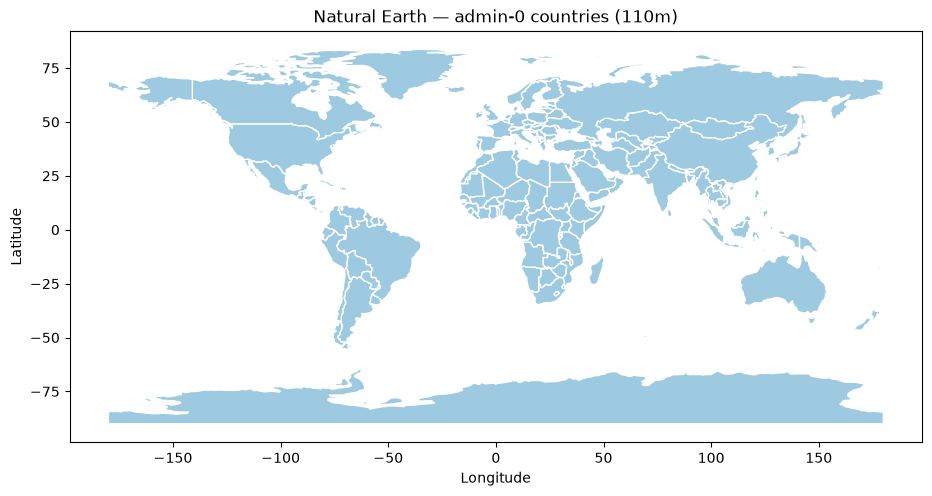

In [3]:
ax = countries.plot(edgecolor='white', facecolor='#9ecae1', figsize=(11, 5.5))
ax.set_title('Natural Earth — admin-0 countries (110m)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## US Census TIGER — states

TIGER cartographic-boundary files arrive in **NAD83 (EPSG:4269)**; the backend
reprojects them to EPSG:4326 so every admin result shares one CRS. The `year=`
selector is optional (defaults to the dataset's vintage).

In [4]:
states = EarthLens(
    data_source='tiger',
    variables=['tiger:state'],
).download(progress_bar=False)
print(len(states), 'state features, EPSG:', states.crs.to_epsg())

2026-06-28 16:47:53.599 | INFO     | earthlens.earthlens:__init__:1012 - No `path` given; download() writes 'tiger' output under earthlens-data\tiger/ (load() uses a temp dir).


2026-06-28 16:47:53.602 | INFO     | earthlens.admin.backend:_fetch:330 - Fetching tiger:state from tiger (/vsizip//vsicurl/https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip)


2026-06-28 16:47:53.603 | INFO     | earthlens.admin.backend:_fetch:332 - tiger license: U.S. Census Bureau TIGER/Line cartographic boundaries, public domain.


2026-06-28 16:47:56.517 | INFO     | earthlens.admin.backend:_fetch:335 - tiger:state: read 56 feature(s)


2026-06-28 16:47:56 | INFO | pyogrio._io | Created 56 records


2026-06-28 16:47:56.613 | INFO     | earthlens.admin.backend:download:412 - admin download summary: 56 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\admin\docs\examples\admin\earthlens-data\tiger\admin_tiger_state.gpkg


56 state features, EPSG: 4326


The 56 features include the 50 states plus DC and territories. We clip the plot to
the contiguous US for readability.

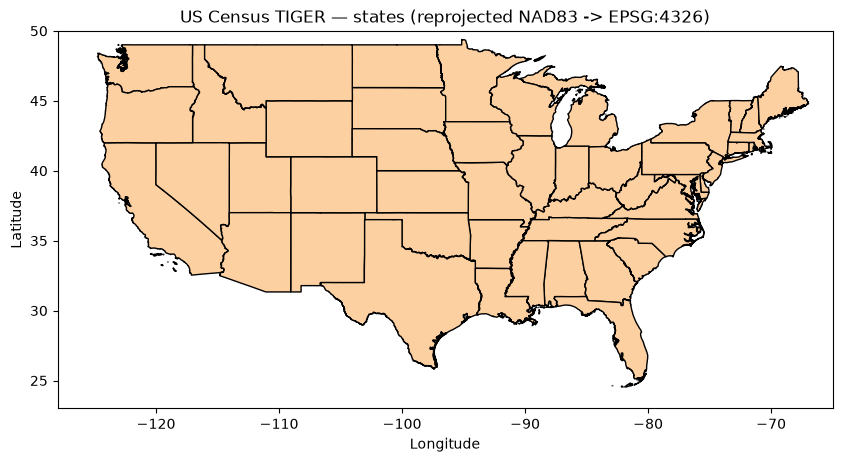

In [5]:
ax = states.plot(edgecolor='black', facecolor='#fdd0a2', figsize=(10, 6))
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
ax.set_title('US Census TIGER — states (reprojected NAD83 -> EPSG:4326)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## A note on CGAZ

The fourth source, **CGAZ** (Comprehensive Global Admin Zones), provides *seamless
global* ADM0/1/2 layers — every country in one file. Those files are large
(160–550 MB), so they are not fetched in this tutorial; use
`variables=['cgaz:adm0']` (no selector) when you need the seamless global layer.
It returns polygons in EPSG:4326 like the others.

## Takeaway

- Natural Earth (`scale=`) and TIGER (`year=` / `state=`) follow the same
  `download()` shape as geoBoundaries.
- The backend normalises every source to **EPSG:4326** — TIGER's NAD83 is
  reprojected automatically.
- `aggregate=` is rejected for all admin datasets: boundaries are vector polygons,
  not a gridded field.